<a href="https://colab.research.google.com/github/singhshubham4422/Edge-Detection-Using-OpenCV/blob/main/Edge_Detection_Using_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install matplotlib opencv-python

Please upload your image (.jpg or .png):


Saving cat.jpg to cat.jpg

✅ Uploaded image: /content/cat.jpg


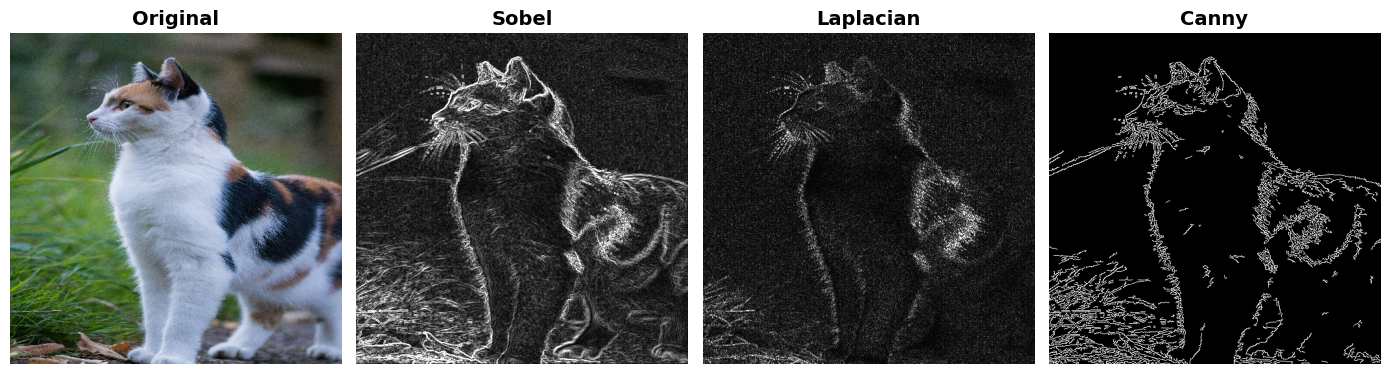


✅ Edge maps saved to: /content/edge_outputs
🖼 Combined comparison figure saved to: ./edge_outputs/edge_comparison.png


In [4]:
import os
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Check if running in Google Colab
try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False


def upload_image():
    """Upload a single image in Colab (.jpg or .png)."""
    if not COLAB:
        raise EnvironmentError("This function works only in Google Colab!")

    print("Please upload your image (.jpg or .png):")
    uploaded = files.upload()

    for filename in uploaded.keys():
        filepath = os.path.join("/content", filename)
        with open(filepath, 'wb') as f:
            f.write(uploaded[filename])
        print(f"\n✅ Uploaded image: {filepath}")
        return filepath


# Upload the image
uploaded_image_path = upload_image()

# Read and preprocess image
img_color = cv2.imread(uploaded_image_path, cv2.IMREAD_COLOR)
img_color = cv2.resize(img_color, (512, 512))
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# Edge detection
edges_sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
edges_sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
edges_sobel = cv2.magnitude(edges_sobel_x, edges_sobel_y)
edges_sobel = cv2.convertScaleAbs(edges_sobel)

edges_laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)
edges_laplacian = cv2.convertScaleAbs(edges_laplacian)

edges_canny = cv2.Canny(img_gray, 100, 200)

# Display results
titles = ['Original', 'Sobel', 'Laplacian', 'Canny']
images = [
    cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB),
    edges_sobel,
    edges_laplacian,
    edges_canny
]

plt.figure(figsize=(14, 6))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    if i == 0:
        plt.imshow(images[i])
    else:
        plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout()

# Save outputs
output_dir = "./edge_outputs"
os.makedirs(output_dir, exist_ok=True)
comparison_path = os.path.join(output_dir, "edge_comparison.png")
plt.savefig(comparison_path, bbox_inches='tight')
plt.show()

# Save individual edge maps
cv2.imwrite(os.path.join(output_dir, "original.png"), img_color)
cv2.imwrite(os.path.join(output_dir, "sobel_edges.png"), edges_sobel)
cv2.imwrite(os.path.join(output_dir, "laplacian_edges.png"), edges_laplacian)
cv2.imwrite(os.path.join(output_dir, "canny_edges.png"), edges_canny)

print(f"\n✅ Edge maps saved to: {os.path.abspath(output_dir)}")
print(f"🖼 Combined comparison figure saved to: {comparison_path}")
